# **Unsupervised Learning**

**Unsupervised Learning** is a type of machine learning where the model is trained on unlabeled data, meaning there is no predefined target or output variable. The algorithm identifies hidden patterns or structures within the data on its own.

**Common Algorithms:**

* K-Means Clustering
* Hierarchical Clustering
* DBSCAN (Density-Based Spatial Clustering)
* Principal Component Analysis (PCA)
* Association Rule Learning

**Example:**
In the Iris dataset, the model is given features such as sepal length, sepal width, petal length, and petal width without any labels. Using **Hierarchical Clustering**, the model builds a tree-like structure (dendrogram) to group similar flowers together, allowing the identification of different species based on feature similarity without prior knowledge of actual classes.


## **Hierarchical Clustering**

### **Import Libraries**

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### **Load & Explore Dataset**

In [47]:
data = load_iris()

X = data.data

df = pd.DataFrame(data=X, columns=data.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [49]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### **Exploratory Data Analtsis (EDA)**

**Pairplot**

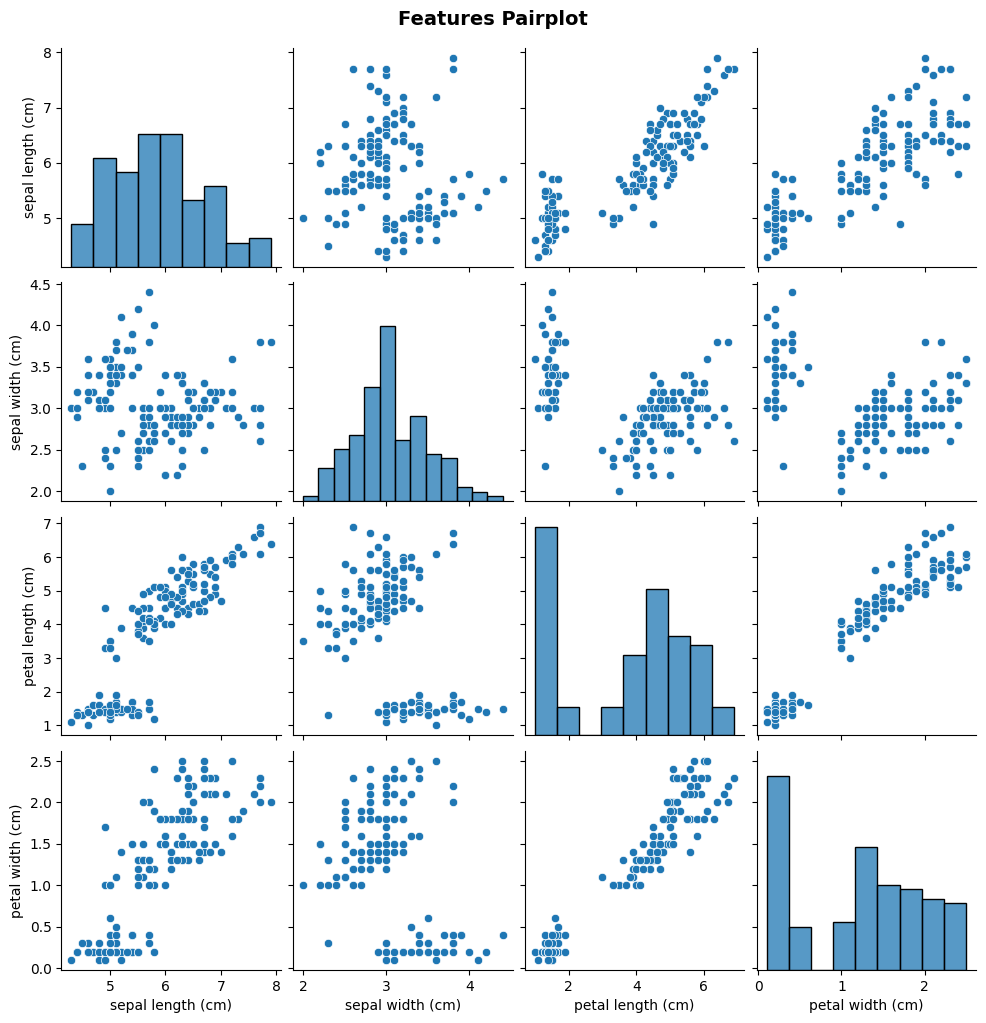

In [50]:
sns.pairplot(df)
plt.suptitle('Features Pairplot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Dendrogram**

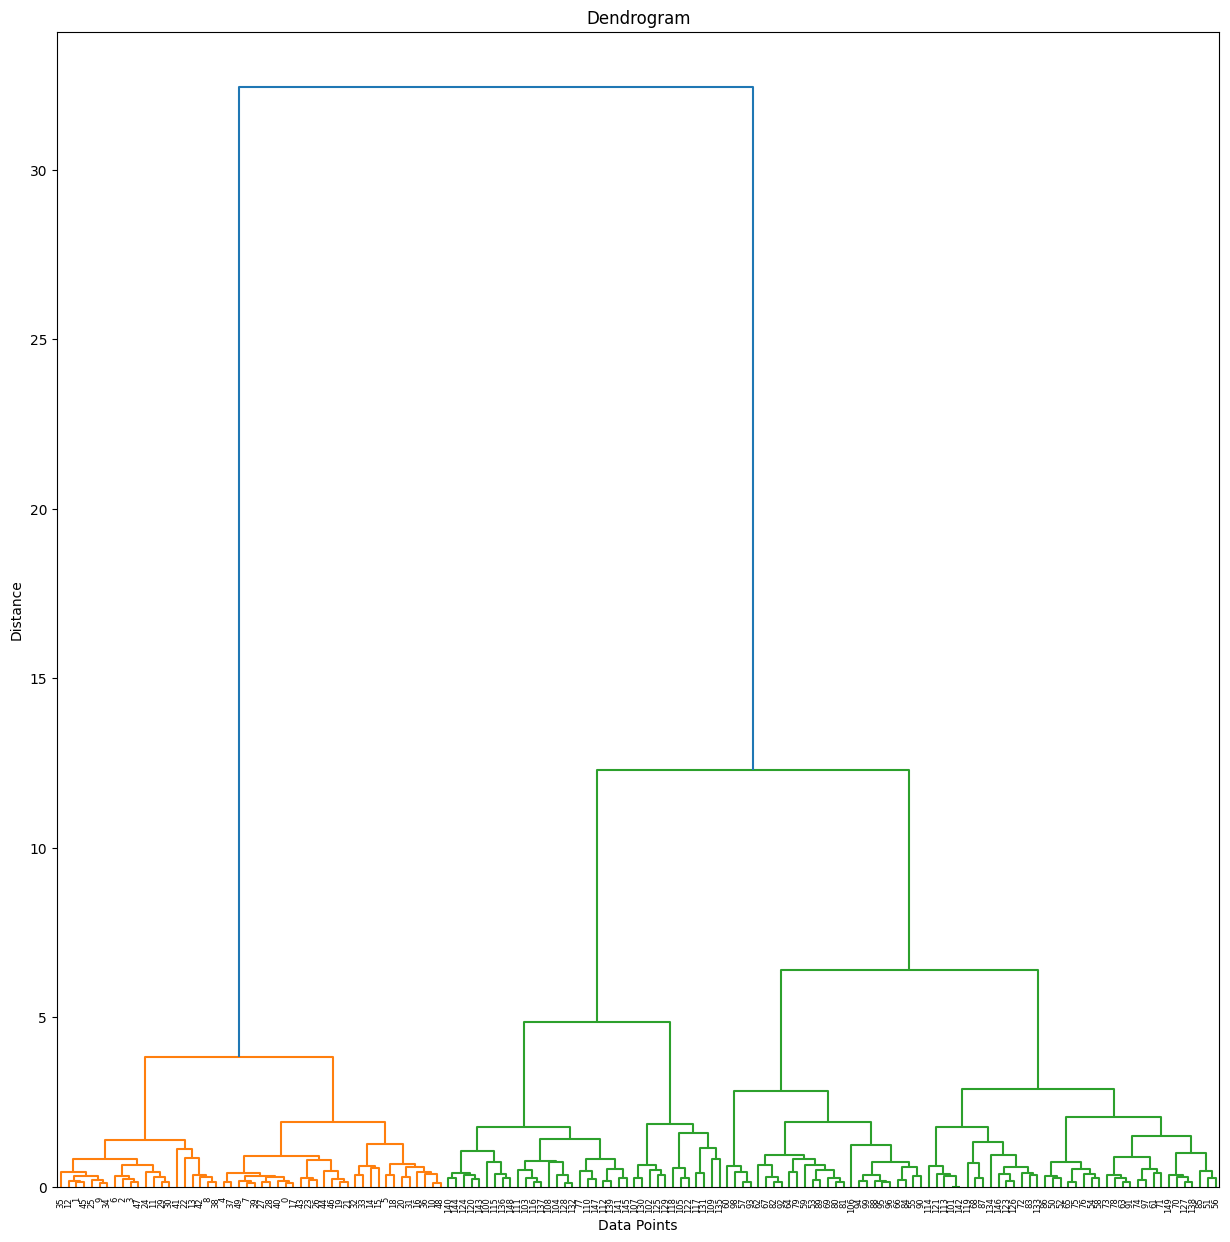

In [51]:
plt.figure(figsize=(15, 15))

sch.dendrogram(
    sch.linkage(X, method="ward"),
    labels=range(len(X)),
    leaf_rotation=90,
    leaf_font_size=6,
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

### **Feature Scalling**

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Apply Hierarchical Clustering**

In [77]:
hc = AgglomerativeClustering(n_clusters=3)
clusters = hc.fit_predict(X)

### **Add Cluster Label**

In [78]:
df["cluster"] = clusters
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,0
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### **Evaluate Model**

In [79]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.45003062405768823


### **Visualize Clusters**

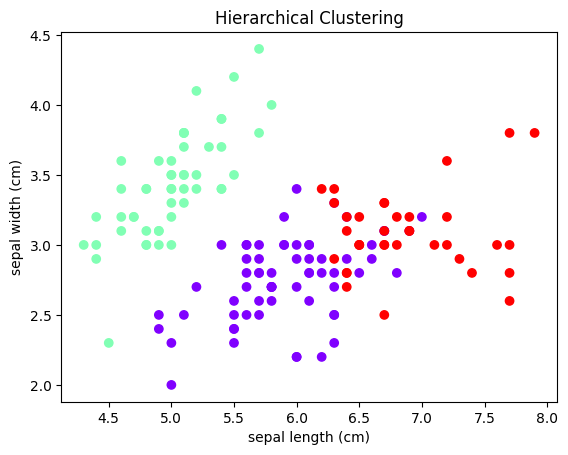

In [80]:
plt.scatter(
    x=df["sepal length (cm)"],
    y=df["sepal width (cm)"],
    c=df["cluster"],
    cmap="rainbow"
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("Hierarchical Clustering")
plt.show()

### **<u>Conclusion:</u>**

* Hierarchical Clustering groups data by merging closest points step by step.

* The dendrogram helps decide the number of clusters.

* This method provides a clear visual understanding of data grouping.